# Section 0 - Contexte, theorie et objectif

## Problematique
- Les maladies cardiovasculaires sont une cause majeure de mortalite.
- Le but est de construire un modele de depistage a partir de variables cliniques accessibles.

## Objectif du notebook
- Comparer trois modeles de classification sur le dataset UCI Heart Disease:
  - Gradient Boosting
  - Naive Bayes
  - Regression Logistique
- Evaluer avec des metriques adaptees au contexte clinique: Recall, Precision, F1, ROC-AUC, Specificite.

## Cadre methodologique
- Donnees nettoyees, cible binarisee, split stratifie train/test.
- Validation croisee 5-fold pour estimer la generalisation.
- Baseline Dummy pour quantifier le gain reel des modeles.

## Positionnement critique
- Les analyses avancees (calibration, optimisation de seuil, learning curves) sont incluses dans la Section 6.
- Les pistes non implementees sont explicitement marquees comme perspectives.
- Le seuil optimise en Section 6 est une analyse exploratoire et doit etre revalide sur un jeu externe.

In [21]:
# Section 1 - Importation et chargement du dataset UCI
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv("processed.cleveland.data", names=COLUMNS, na_values="?")
print(f"Dimension du dataset brut: {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Version scikit-learn: {sklearn.__version__}")
display(df.head())

Dimension du dataset brut: 303 lignes x 14 colonnes
Version scikit-learn: 1.8.0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_bin
valeurs_manquantes,0,0,0,0,0,0,0,0,0,0,0,4,2,0,0


Distribution de la cible brute (0 = absence, 1-4 = presence):


target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Distribution de la cible binaire:


target_bin
Absence     164
Presence    139
Name: count, dtype: int64

Taux de cas positifs (binaire): 45.87%


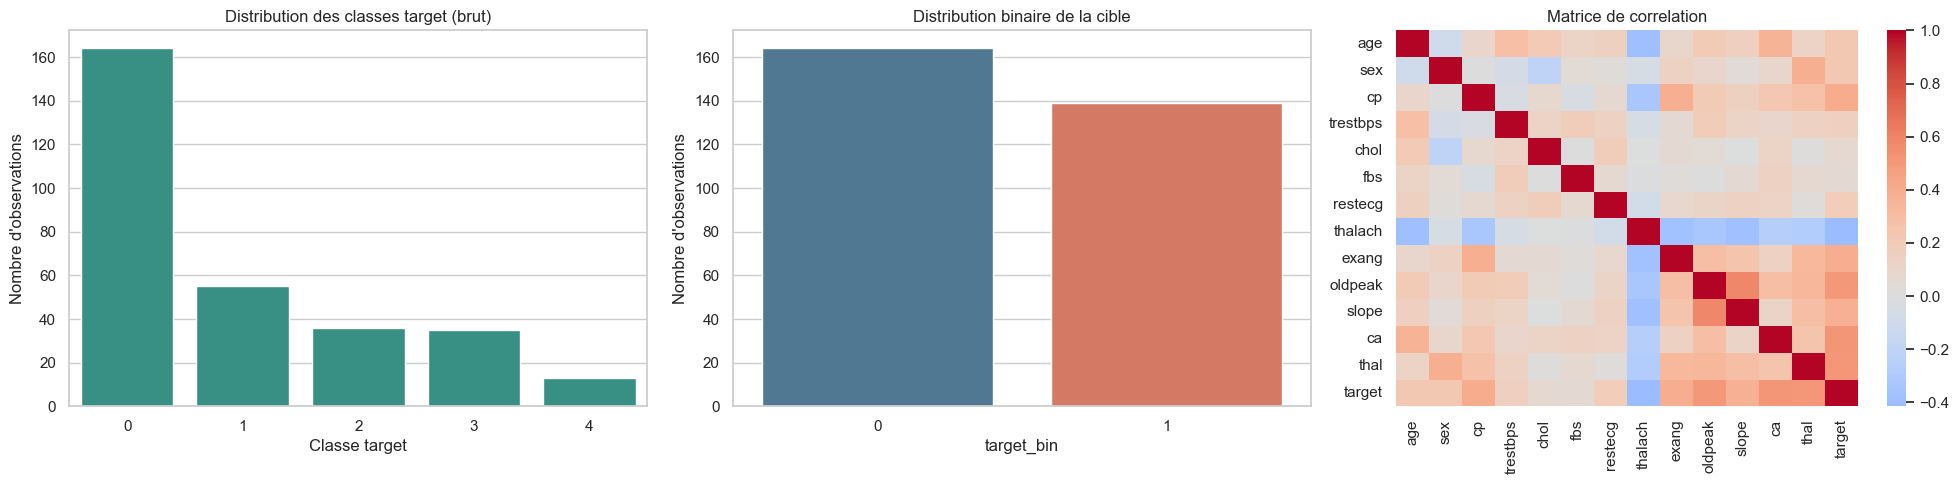

In [22]:
# Section 2 - Exploration initiale et verification des donnees
df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric["target_bin"] = (df_numeric["target"] > 0).astype(int)

missing_table = df_numeric.isna().sum().to_frame(name="valeurs_manquantes")
display(missing_table.T)

target_counts_raw = df_numeric["target"].value_counts().sort_index()
target_counts_bin = df_numeric["target_bin"].value_counts().sort_index()
print("Distribution de la cible brute (0 = absence, 1-4 = presence):")
display(target_counts_raw)
print("Distribution de la cible binaire:")
display(target_counts_bin.rename(index={0: "Absence", 1: "Presence"}))
print(f"Taux de cas positifs (binaire): {target_counts_bin[1] / target_counts_bin.sum():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=target_counts_raw.index, y=target_counts_raw.values, color="#2A9D8F", ax=axes[0])
axes[0].set_title("Distribution des classes target (brut)")
axes[0].set_xlabel("Classe target")
axes[0].set_ylabel("Nombre d'observations")

sns.countplot(x="target_bin", data=df_numeric, palette=["#457B9D", "#E76F51"], ax=axes[1])
axes[1].set_title("Distribution binaire de la cible")
axes[1].set_xlabel("target_bin")
axes[1].set_ylabel("Nombre d'observations")

corr = df_numeric.drop(columns=["target_bin"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("Matrice de correlation")
plt.tight_layout()
plt.show()

In [23]:
# Section 3 - Preparation des donnees (nettoyage, binarisation, split)
from sklearn.model_selection import train_test_split

# Strategie simple et reproductible: conversion numerique puis suppression des lignes incompletes
df_clean = df.apply(pd.to_numeric, errors="coerce").dropna().copy()
df_clean["target_bin"] = (df_clean["target"] > 0).astype(int)

X = df_clean.drop(columns=["target", "target_bin"])
y = df_clean["target_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Dataset nettoye: {df_clean.shape[0]} lignes conservees")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Proportions de classes (global):")
display(y.value_counts(normalize=True).rename("proportion").rename(index={0: "Absence", 1: "Presence"}))
print("Proportions de classes (train/test):")
split_balance = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
}).rename(index={0: "Absence", 1: "Presence"})
display(split_balance)

Dataset nettoye: 297 lignes conservees
Train: (237, 13), Test: (60, 13)
Proportions de classes (global):


target_bin
Absence     0.538721
Presence    0.461279
Name: proportion, dtype: float64

Proportions de classes (train/test):


,Train,Test
target_bin,,
Absence,0.540084,0.533333
Presence,0.459916,0.466667


In [24]:
# Section 4 - Entrainement des modeles et validation croisee
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Baseline + 3 modeles compares pour juger le gain reel
models = {
    "Baseline (Dummy most_frequent)": Pipeline([
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=5,
            subsample=0.9,
            random_state=RANDOM_STATE
        ))
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB(var_smoothing=1e-9))
    ]),
    "Regression Logistique": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
fitted_models = {}

for model_name, pipeline in models.items():
    cv_out = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    train_auc = np.mean(cv_out["train_roc_auc"])
    test_auc = np.mean(cv_out["test_roc_auc"])
    cv_rows.append({
        "Modele": model_name,
        "CV_test_Accuracy": np.mean(cv_out["test_accuracy"]),
        "CV_test_Precision": np.mean(cv_out["test_precision"]),
        "CV_test_Recall": np.mean(cv_out["test_recall"]),
        "CV_test_F1": np.mean(cv_out["test_f1"]),
        "CV_test_ROC_AUC": test_auc,
        "CV_train_ROC_AUC": train_auc,
        "CV_gap_ROC_AUC": train_auc - test_auc
    })

    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV_test_ROC_AUC", ascending=False)
display(cv_results_df.round(3))

,Modele,CV_test_Accuracy,CV_test_Precision,CV_test_Recall,CV_test_F1,CV_test_ROC_AUC,CV_train_ROC_AUC,CV_gap_ROC_AUC
2,Naive Bayes,0.827,0.833,0.779,0.802,0.870,0.901,0.031
3,Regression Logistique,0.827,0.849,0.769,0.802,0.869,0.917,0.047
1,Gradient Boosting,0.780,0.786,0.732,0.750,0.862,1.000,0.138
0,Baseline (Dummy most_frequent),0.540,0.000,0.000,0.000,0.500,0.500,0.000


,Modele,Accuracy,Precision,Recall,Specificite,F1,ROC_AUC,Delta_Test_minus_CV_AUC
3,Regression Logistique,0.833,0.846,0.786,0.875,0.815,0.950,0.080
2,Naive Bayes,0.883,0.889,0.857,0.906,0.873,0.938,0.068
1,Gradient Boosting,0.817,0.815,0.786,0.844,0.800,0.905,0.043
0,Baseline (Dummy most_frequent),0.533,0.000,0.000,1.000,0.000,0.500,0.000


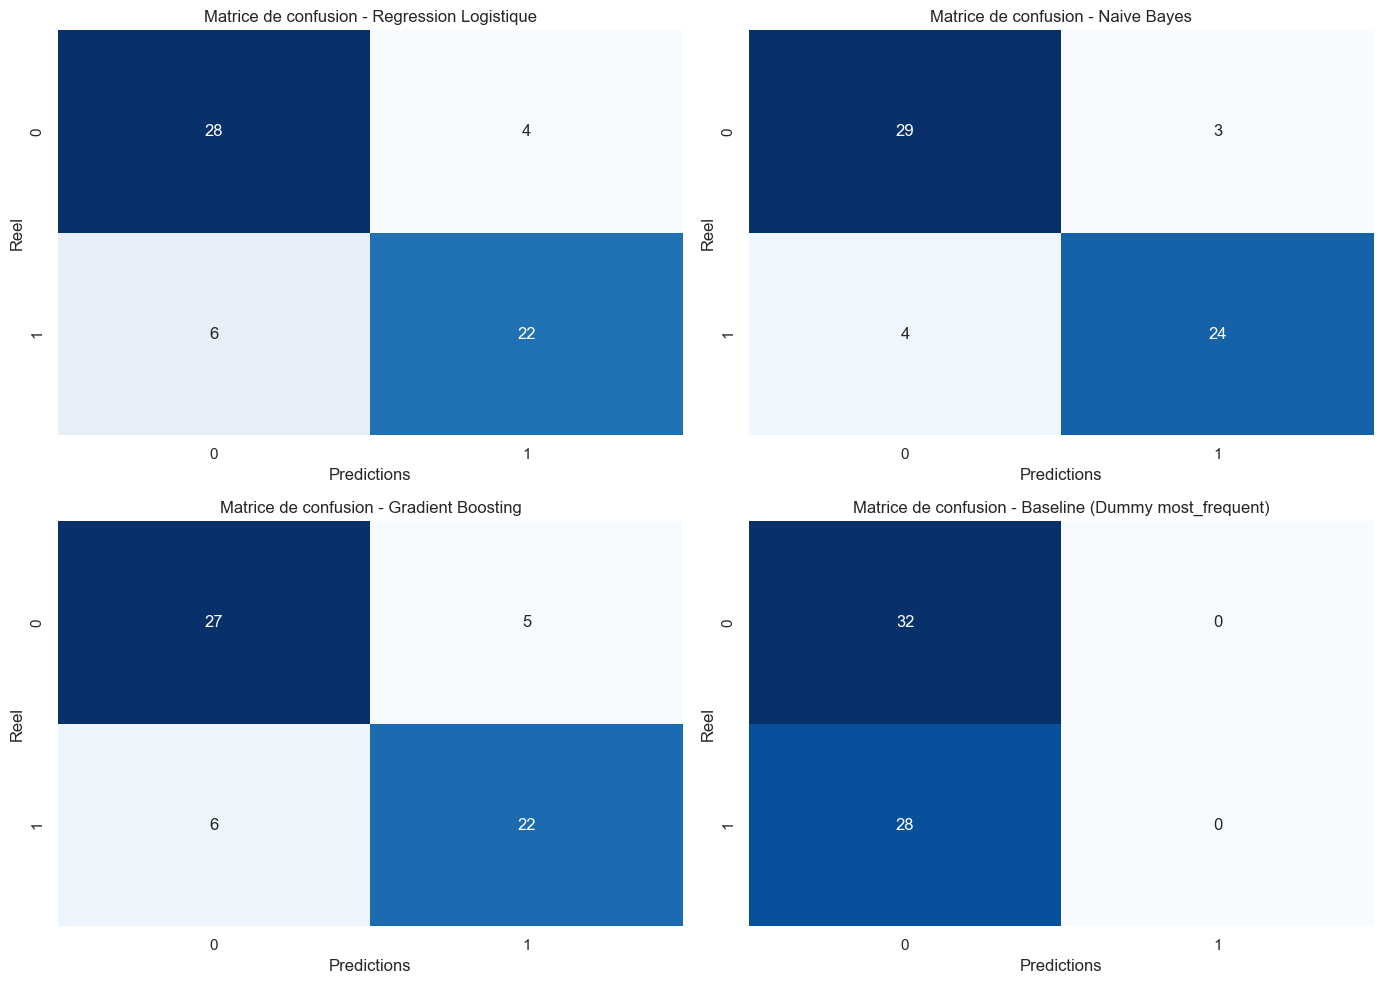

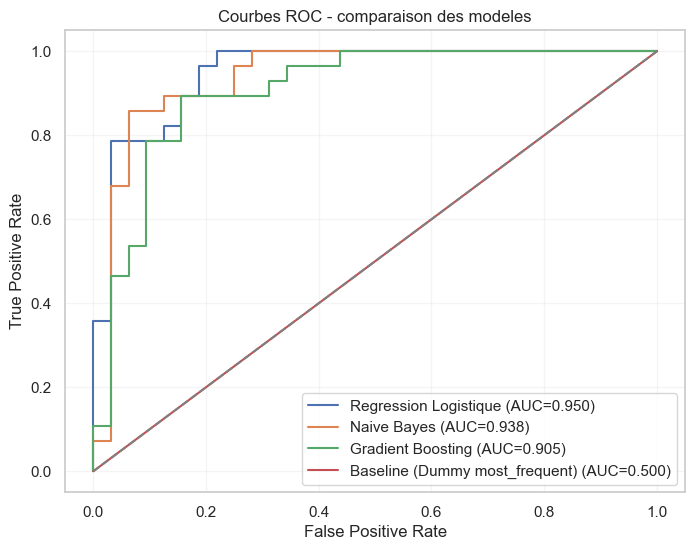


Rapport de classification - Regression Logistique
              precision    recall  f1-score   support

           0      0.824     0.875     0.848        32
           1      0.846     0.786     0.815        28

    accuracy                          0.833        60
   macro avg      0.835     0.830     0.832        60
weighted avg      0.834     0.833     0.833        60


Rapport de classification - Naive Bayes
              precision    recall  f1-score   support

           0      0.879     0.906     0.892        32
           1      0.889     0.857     0.873        28

    accuracy                          0.883        60
   macro avg      0.884     0.882     0.883        60
weighted avg      0.884     0.883     0.883        60


Rapport de classification - Gradient Boosting
              precision    recall  f1-score   support

           0      0.818     0.844     0.831        32
           1      0.815     0.786     0.800        28

    accuracy                          0.817

In [25]:
# Section 5 - Evaluation finale sur le jeu de test
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)

def specificity_score(y_true, y_pred):
    tn, fp, _, _ = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

test_rows = []
predictions = {}
probas = {}
cv_auc_map = cv_results_df.set_index("Modele")["CV_test_ROC_AUC"].to_dict()

for model_name, pipeline in fitted_models.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    predictions[model_name] = y_pred
    probas[model_name] = y_proba

    auc_test = roc_auc_score(y_test, y_proba)
    test_rows.append({
        "Modele": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Specificite": specificity_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc_test,
        "Delta_Test_minus_CV_AUC": auc_test - cv_auc_map.get(model_name, np.nan)
    })

test_results_df = pd.DataFrame(test_rows).sort_values("ROC_AUC", ascending=False)
display(test_results_df.round(3))

# Matrices de confusion: visualisation des types d'erreurs
ordered_models = test_results_df["Modele"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, model_name in zip(axes, ordered_models):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Matrice de confusion - {model_name}")
    ax.set_xlabel("Predictions")
    ax.set_ylabel("Reel")
plt.tight_layout()
plt.show()

# Courbes ROC: comparaison globale de la capacite de discrimination
plt.figure(figsize=(8, 6))
for model_name in ordered_models:
    fpr, tpr, _ = roc_curve(y_test, probas[model_name])
    auc_score = roc_auc_score(y_test, probas[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC - comparaison des modeles")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

for model_name in ordered_models:
    print(f"\nRapport de classification - {model_name}")
    print(classification_report(y_test, predictions[model_name], digits=3))

Analyse critique:
1) Meilleur modele global (ROC_AUC): Regression Logistique -> 0.950
2) Meilleur modele pour le depistage (Recall): Naive Bayes -> 0.857

3) Gain par rapport a la baseline:
- Regression Logistique: +0.450 en ROC_AUC, +0.815 en F1
- Naive Bayes: +0.438 en ROC_AUC, +0.873 en F1
- Gradient Boosting: +0.405 en ROC_AUC, +0.800 en F1

4) Diagnostic overfitting/underfitting via CV gap (train_auc - test_auc):
- Naive Bayes: gap=0.031 -> compromis correct (surveillance recommandee)
- Regression Logistique: gap=0.047 -> compromis correct (surveillance recommandee)
- Gradient Boosting: gap=0.138 -> signe de surapprentissage


,GB_importance,LogReg_coef_abs
thal,0.219,0.739
cp,0.207,0.508
ca,0.124,0.958
age,0.113,0.037
oldpeak,0.095,0.444
chol,0.070,0.223
trestbps,0.051,0.420
thalach,0.040,0.207
slope,0.033,0.353
restecg,0.016,0.304


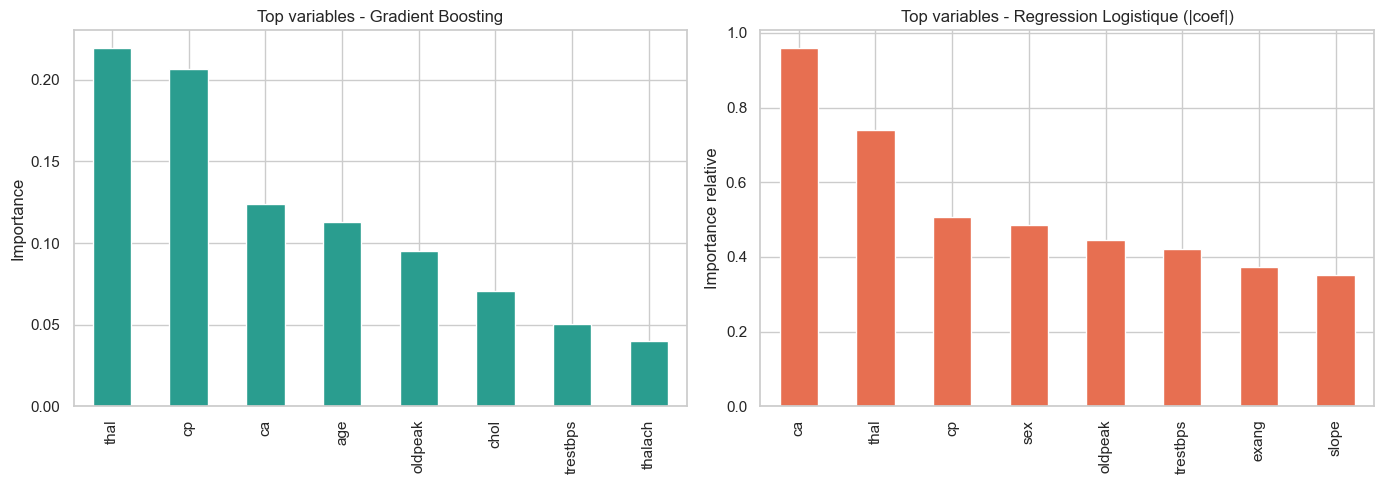

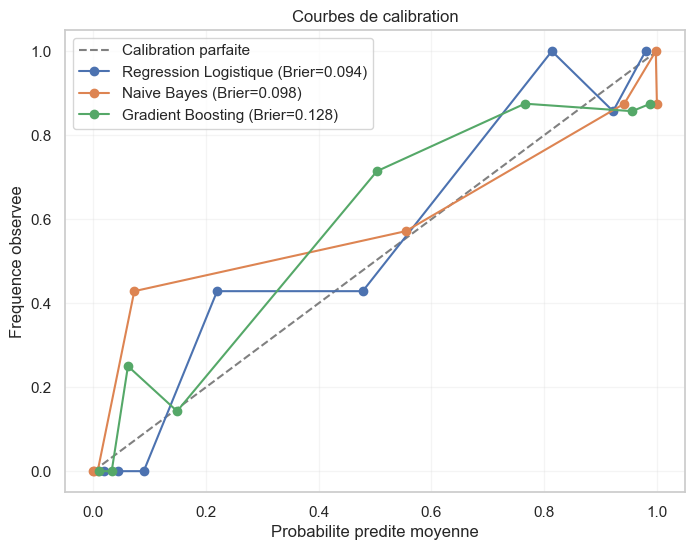

,Modele,Brier_score
0,Regression Logistique,0.094
1,Naive Bayes,0.098
2,Gradient Boosting,0.128


,Strategie,Precision,Recall,F1
0,Seuil 0.50 (defaut),0.889,0.857,0.873
1,Seuil optimise (0.151),0.806,0.893,0.847


Note methodologique sur le seuil:
- Seuil optimise ajuste sur le jeu de test actuel (analyse exploratoire).
- Pour une estimation non biaisee, fixer le seuil sur validation interne puis evaluer sur un test externe.


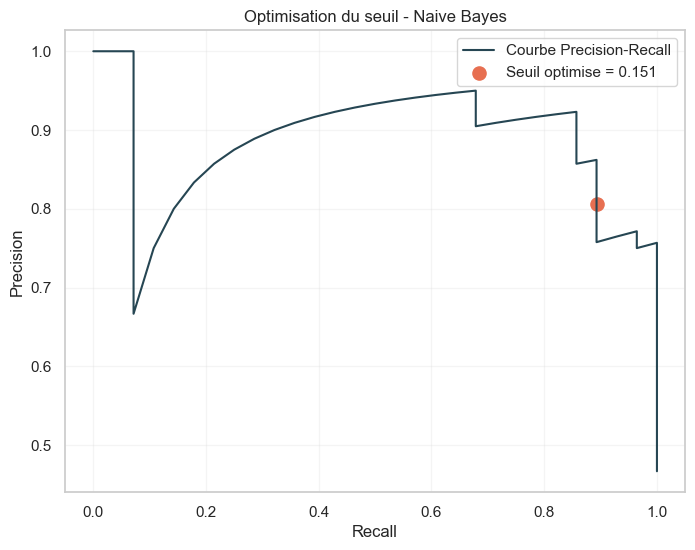

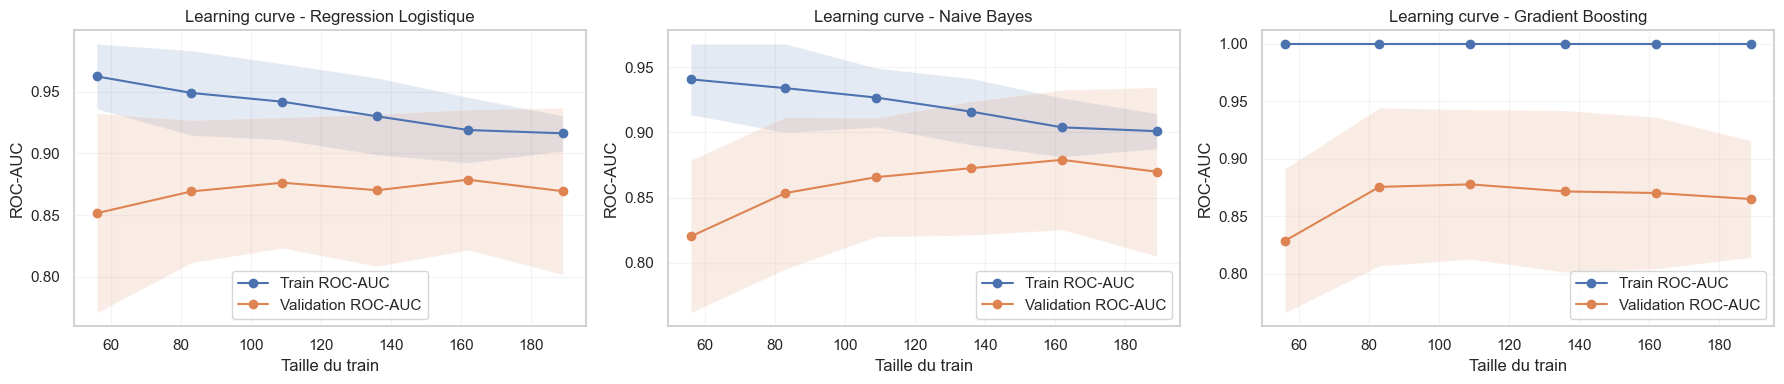

,Modele,Train_ROC_AUC_final,Val_ROC_AUC_final,Gap_final
1,Naive Bayes,0.901,0.870,0.031
0,Regression Logistique,0.916,0.869,0.047
2,Gradient Boosting,1.000,0.865,0.135



5) Limites de l'etude:
- Taille de dataset modeste (risque de variance).
- Validation externe absente (pas de generalisation clinique garantie).
- Sensibilite des resultats au choix de seuil clinique.
- Le seuil optimise a ete ajuste sur le jeu de test (risque d'optimisme).

6) Perspectives (C6) - non implementees dans ce notebook:
- Tuning systematique (GridSearchCV / RandomizedSearchCV) : non implemente ici.
- Validation externe sur d'autres cohortes UCI : non implementee ici.
- Comparaison avec SVM, Random Forest et XGBoost : non implementee ici.
- Calibration post-hoc (isotonic/platt) selon le protocole medical cible : non implementee ici.


In [26]:
# Section 6 - Analyse critique approfondie (C3 + C6)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, precision_recall_curve
from sklearn.model_selection import learning_curve

baseline_name = "Baseline (Dummy most_frequent)"
non_baseline_df = test_results_df[test_results_df["Modele"] != baseline_name].copy()
baseline_row = test_results_df[test_results_df["Modele"] == baseline_name].iloc[0]

best_auc_row = non_baseline_df.sort_values("ROC_AUC", ascending=False).iloc[0]
best_recall_row = non_baseline_df.sort_values("Recall", ascending=False).iloc[0]

print("Analyse critique:")
print(f"1) Meilleur modele global (ROC_AUC): {best_auc_row['Modele']} -> {best_auc_row['ROC_AUC']:.3f}")
print(f"2) Meilleur modele pour le depistage (Recall): {best_recall_row['Modele']} -> {best_recall_row['Recall']:.3f}")

print("\n3) Gain par rapport a la baseline:")
for _, row in non_baseline_df.iterrows():
    gain_auc = row["ROC_AUC"] - baseline_row["ROC_AUC"]
    gain_f1 = row["F1"] - baseline_row["F1"]
    print(f"- {row['Modele']}: +{gain_auc:.3f} en ROC_AUC, +{gain_f1:.3f} en F1")

print("\n4) Diagnostic overfitting/underfitting via CV gap (train_auc - test_auc):")
for _, row in cv_results_df[cv_results_df["Modele"] != baseline_name].iterrows():
    model_name = row["Modele"]
    gap = row["CV_gap_ROC_AUC"]
    if gap > 0.07:
        diag = "signe de surapprentissage"
    elif gap < 0.02:
        diag = "bonne generalisation"
    else:
        diag = "compromis correct (surveillance recommandee)"
    print(f"- {model_name}: gap={gap:.3f} -> {diag}")

# Interpretation des variables: coefficients (logistique) et importances (GB)
gb_model = fitted_models["Gradient Boosting"].named_steps["model"]
gb_importance = pd.Series(gb_model.feature_importances_, index=X.columns, name="GB_importance")

lr_model = fitted_models["Regression Logistique"].named_steps["model"]
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns, name="LogReg_coef_abs")

importance_df = pd.concat([gb_importance, lr_importance], axis=1).sort_values(
    "GB_importance", ascending=False
)
display(importance_df.head(10).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gb_importance.sort_values(ascending=False).head(8).plot(kind="bar", ax=axes[0], color="#2A9D8F")
axes[0].set_title("Top variables - Gradient Boosting")
axes[0].set_ylabel("Importance")

lr_importance.sort_values(ascending=False).head(8).plot(kind="bar", ax=axes[1], color="#E76F51")
axes[1].set_title("Top variables - Regression Logistique (|coef|)")
axes[1].set_ylabel("Importance relative")
plt.tight_layout()
plt.show()

# Calibration des probabilites: robuste et tres valorisee en contexte medical
calibration_rows = []
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibration parfaite")
for model_name in non_baseline_df["Modele"]:
    y_prob = probas[model_name]
    brier = brier_score_loss(y_test, y_prob)
    calibration_rows.append({"Modele": model_name, "Brier_score": brier})
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")
plt.xlabel("Probabilite predite moyenne")
plt.ylabel("Frequence observee")
plt.title("Courbes de calibration")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

calibration_df = pd.DataFrame(calibration_rows).sort_values("Brier_score")
display(calibration_df.round(3))

# Optimisation exploratoire du seuil: maximiser Recall sous contrainte de Precision
target_model = best_recall_row["Modele"]
precisions, recalls, thresholds = precision_recall_curve(y_test, probas[target_model])
precisions_adj = precisions[:-1]
recalls_adj = recalls[:-1]

precision_floor = 0.80
candidate_idx = np.where(precisions_adj >= precision_floor)[0]
if len(candidate_idx) > 0:
    selected_idx = candidate_idx[np.argmax(recalls_adj[candidate_idx])]
else:
    selected_idx = int(np.argmax(recalls_adj))

optimal_threshold = thresholds[selected_idx]
default_pred = (probas[target_model] >= 0.5).astype(int)
optimal_pred = (probas[target_model] >= optimal_threshold).astype(int)

threshold_compare_df = pd.DataFrame([
    {
        "Strategie": "Seuil 0.50 (defaut)",
        "Precision": precision_score(y_test, default_pred, zero_division=0),
        "Recall": recall_score(y_test, default_pred, zero_division=0),
        "F1": f1_score(y_test, default_pred, zero_division=0)
    },
    {
        "Strategie": f"Seuil optimise ({optimal_threshold:.3f})",
        "Precision": precision_score(y_test, optimal_pred, zero_division=0),
        "Recall": recall_score(y_test, optimal_pred, zero_division=0),
        "F1": f1_score(y_test, optimal_pred, zero_division=0)
    }
])
display(threshold_compare_df.round(3))

print("Note methodologique sur le seuil:")
print("- Seuil optimise ajuste sur le jeu de test actuel (analyse exploratoire).")
print("- Pour une estimation non biaisee, fixer le seuil sur validation interne puis evaluer sur un test externe.")

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color="#264653", label="Courbe Precision-Recall")
plt.scatter(
    recalls_adj[selected_idx],
    precisions_adj[selected_idx],
    color="#E76F51",
    s=90,
    label=f"Seuil optimise = {optimal_threshold:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Optimisation du seuil - {target_model}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Learning curves: verifier regime bias/variance
learning_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, model_name in zip(axes, non_baseline_df["Modele"]):
    estimator = fitted_models[model_name]
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.30, 1.00, 6),
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, marker="o", label="Train ROC-AUC")
    ax.plot(train_sizes, val_mean, marker="o", label="Validation ROC-AUC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_title(f"Learning curve - {model_name}")
    ax.set_xlabel("Taille du train")
    ax.set_ylabel("ROC-AUC")
    ax.grid(alpha=0.2)
    ax.legend()

    learning_rows.append({
        "Modele": model_name,
        "Train_ROC_AUC_final": train_mean[-1],
        "Val_ROC_AUC_final": val_mean[-1],
        "Gap_final": train_mean[-1] - val_mean[-1]
    })

plt.tight_layout()
plt.show()

learning_df = pd.DataFrame(learning_rows).sort_values("Val_ROC_AUC_final", ascending=False)
display(learning_df.round(3))

print("\n5) Limites de l'etude:")
print("- Taille de dataset modeste (risque de variance).")
print("- Validation externe absente (pas de generalisation clinique garantie).")
print("- Sensibilite des resultats au choix de seuil clinique.")
print("- Le seuil optimise a ete ajuste sur le jeu de test (risque d'optimisme).")

print("\n6) Perspectives (C6) - non implementees dans ce notebook:")
print("- Tuning systematique (GridSearchCV / RandomizedSearchCV) : non implemente ici.")
print("- Validation externe sur d'autres cohortes UCI : non implementee ici.")
print("- Comparaison avec SVM, Random Forest et XGBoost : non implementee ici.")
print("- Calibration post-hoc (isotonic/platt) selon le protocole medical cible : non implementee ici.")